<a href="https://colab.research.google.com/github/DANUSHMATHI2002/Final-Project_Predicting-Chemical-Bioconcentration-in-Fish-Using-Machine-Learning/blob/main/Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **1. Installing and Importing Libraries**

In [1]:
!pip install ucimlrepo

In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

In [3]:
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

print("Libraries loaded successfully!")

Libraries loaded successfully!


## **2. Load the Dataset**

In [9]:
df = pd.read_csv('/content/Fish_concentration.csv')

# Creating binary target (1 = Dangerous, 0 = Safe)
df['is_dangerous'] = df['Class'].apply(lambda x: 1 if x in [1, 2] else 0)

# Features list
feature_cols = ['nHM', 'piPC09', 'PCD', 'X2Av', 'MLOGP', 'ON1V', 'N-072', 'B02[C-N]', 'F04[C-O]']

print(f"Data loaded: {df.shape[0]} chemicals")
print(f"Safe: {(df['is_dangerous']==0).sum()}, Dangerous: {(df['is_dangerous']==1).sum()}")

Data loaded: 779 chemicals
Safe: 255, Dangerous: 524


# **Plot 1: Bar Chart (Class Distribution)**

Purpose: See if the data is imbalanced.


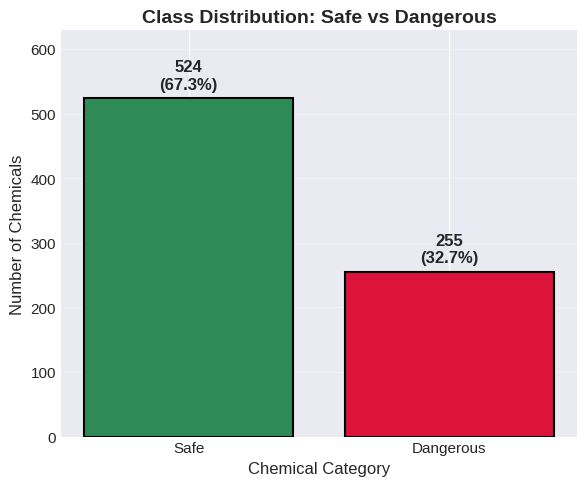

In [11]:
plt.figure(figsize=(6, 5))
counts = df['is_dangerous'].value_counts()
colors = ['#2E8B57', '#DC143C']  # SeaGreen for Safe, Crimson for Dangerous

bars = plt.bar(['Safe', 'Dangerous'], counts, color=colors, edgecolor='black', linewidth=1.5)

for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             f'{count}\n({count/len(df)*100:.1f}%)',
             ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.title('Class Distribution: Safe vs Dangerous', fontsize=14, fontweight='bold')
plt.xlabel('Chemical Category', fontsize=12)
plt.ylabel('Number of Chemicals', fontsize=12)
plt.ylim(0, counts.max() * 1.2)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# **Plot 2: Box Plots (Features by Class)**

Purpose: Find which features best separate Safe from Dangerous.

In [12]:
# Prepare data
df_melt = df.melt(id_vars=['is_dangerous'], value_vars=feature_cols)
df_melt['Class'] = df_melt['is_dangerous'].map({0: 'Safe', 1: 'Dangerous'})
